In [20]:
# =============================================================================
# Интерпретация KAN-модели PhysicsKAN (Exp 2.6.x)
# =============================================================================
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
import polars as pl
import importlib
from pathlib import Path

# Добавляем корень проекта в путь
ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

# Перезагружаем визуализацию, если правили её в .py файлах
import osc_tools.visualization.kan_plot
importlib.reload(osc_tools.visualization.kan_plot)
from osc_tools.visualization.kan_plot import plot_kan_layer_grid

from osc_tools.ml.dataset import OscillogramDataset
from osc_tools.ml.labels import prepare_labels_for_experiment, get_target_columns
from scripts.evaluation.aggregate_reports import _create_model_from_config, _load_state_dict_safe
from scripts.evaluation.plot_model_marking import (
    _find_experiment_dir, _resolve_feature_mode, _resolve_sampling_strategy,
    _resolve_num_harmonics, _resolve_target_level, json_load
)

# === НАСТРОЙКИ ===
EXP_NAME = "Exp_2.6.1_PhysicsKAN_medium_phase_polar_stride_base_weights_aug"
FIGURES_DIR = ROOT_DIR / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Experiment: {EXP_NAME}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Experiment: Exp_2.6.1_PhysicsKAN_medium_phase_polar_stride_base_weights_aug
Figures will be saved to: D:\Программирование\Fork\Scientific_research_osc_ML\reports\figures


In [21]:
# === Загрузка модели ===
exp_dir = _find_experiment_dir(EXP_NAME)
config = json_load(exp_dir / "config.json")

model = _create_model_from_config(config)
ckpt_path = exp_dir / "best_model.pt"
if not ckpt_path.exists():
    ckpt_path = exp_dir / "final_model.pt"

print(f"Загрузка весов из: {ckpt_path}")
checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
_load_state_dict_safe(model, checkpoint, exp_dir.name, "notebook")
model.eval()

print(f"Модель: {config['model']['name']}")
print(f"Чекпоинт: {ckpt_path.name}")

# Краткий обзор модели
total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")
if hasattr(model, 'processing_net'):
    print("Архитектура: PhysicsKAN (with processing_net)")
elif hasattr(model, 'features'):
    print("Архитектура: PhysicsKANConditional (with separate heads)")

Загрузка весов из: D:\Программирование\Fork\Scientific_research_osc_ML\experiments\phase2_6\Exp_2.6.1\Exp_2.6.1_PhysicsKAN_medium_phase_polar_stride_base_weights_aug\best_model.pt
Модель: PhysicsKAN
Чекпоинт: best_model.pt
Всего параметров: 144,960
Архитектура: PhysicsKAN (with processing_net)


In [22]:
# === Загрузка тестовых данных для анализа ===
test_csv_path = ROOT_DIR / 'data' / 'ml_datasets' / 'test.csv'

if test_csv_path.exists():
    print(f"Loading data from {test_csv_path.name}...")
    df_test = pl.read_csv(test_csv_path)
    
    # Резолвим параметры из конфига модели и названия эксперимента
    target_level = _resolve_target_level(EXP_NAME)
    feature_mode = _resolve_feature_mode(config, EXP_NAME)
    
    # Параметры модели для резолвинга гармоник
    input_size = config['model']['params'].get('input_size', 0)
    in_channels_model = config['model']['params'].get('in_channels', 8)
    window_size = config['data'].get('window_size', 640)
    
    # Определяем стратегию (stride/snapshot) и число гармоник
    sampling_strategy, stride = _resolve_sampling_strategy(EXP_NAME, input_size, in_channels_model, window_size)
    num_harmonics, _ = _resolve_num_harmonics(
        feature_mode, sampling_strategy, stride, window_size, in_channels_model, input_size
    )
    
    print(f"Resolved resolution: mode={feature_mode}, harm={num_harmonics}, strategy={sampling_strategy}, stride={stride}")

    # ПОДГОТОВКА МЕТОК
    df_test = prepare_labels_for_experiment(df_test, target_level)
    target_columns = get_target_columns(target_level, df=df_test)
    
    # Создаем индексы
    indices = np.arange(0, len(df_test) - window_size, window_size // 2)
    
    ds = OscillogramDataset(
        dataframe=df_test,
        indices=indices,
        window_size=window_size,
        feature_mode=feature_mode,
        target_columns=target_columns,
        sampling_strategy=sampling_strategy,
        downsampling_stride=stride,
        num_harmonics=num_harmonics,
        target_level=target_level
    )
    print(f"Dataset created: {len(ds)} samples, feature_mode={feature_mode}, harm={num_harmonics}")
    
    # Проверка совпадения каналов
    x_test, _ = ds[0]
    print(f"Actual data channels: {x_test.shape[0]}, Model expects: {in_channels_model}")
    if x_test.shape[0] != in_channels_model:
         print(f"ПРЕДУПРЕЖДЕНИЕ: Каналы не совпадают! {x_test.shape[0]} != {in_channels_model}")
else:
    print(f"ПРЕДУПРЕЖДЕНИЕ: {test_csv_path} не найден.")

Loading data from test.csv...
Resolved resolution: mode=phase_polar, harm=3, strategy=stride, stride=16
Dataset created: 1989 samples, feature_mode=phase_polar, harm=3
Actual data channels: 48, Model expects: 48


## Визуализация KAN-слоёв в PhysicsKAN

PhysicsKAN содержит ConvKAN в блоке `processing_net`.
Мы посмотрим, какие формы функций активации выучены в первом сверточном KAN-слое и в первом слое классификатора.
Это помогает понять, какие нелинейности использует модель.

Conv KAN Layer: in=288, out=16


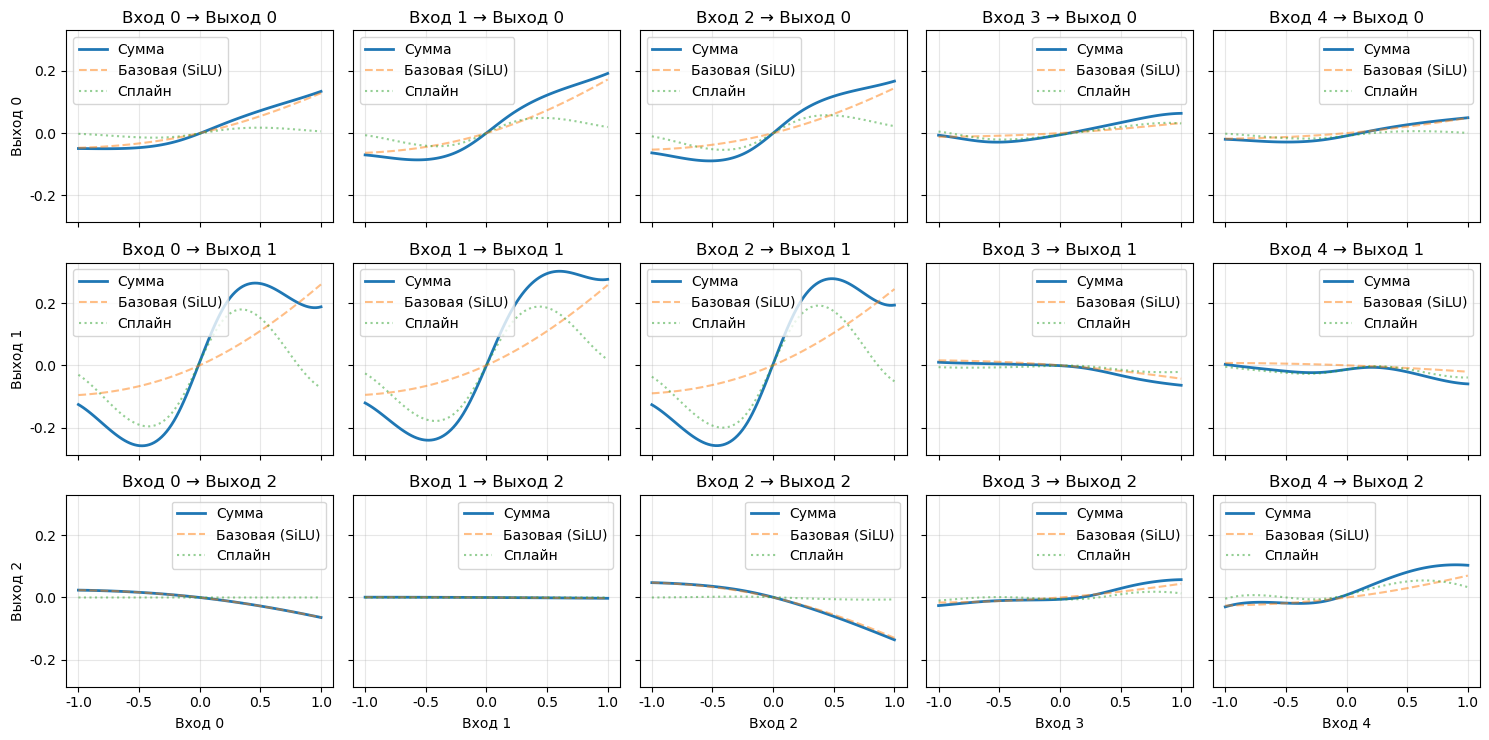

Сохранено: D:\Программирование\Fork\Scientific_research_osc_ML\reports\figures\Exp_2.6.1_PhysicsKAN_medium_phase_polar_stride_base_weights_aug_kan_conv_layer0.png
Classifier KAN Layer: in=64, out=32


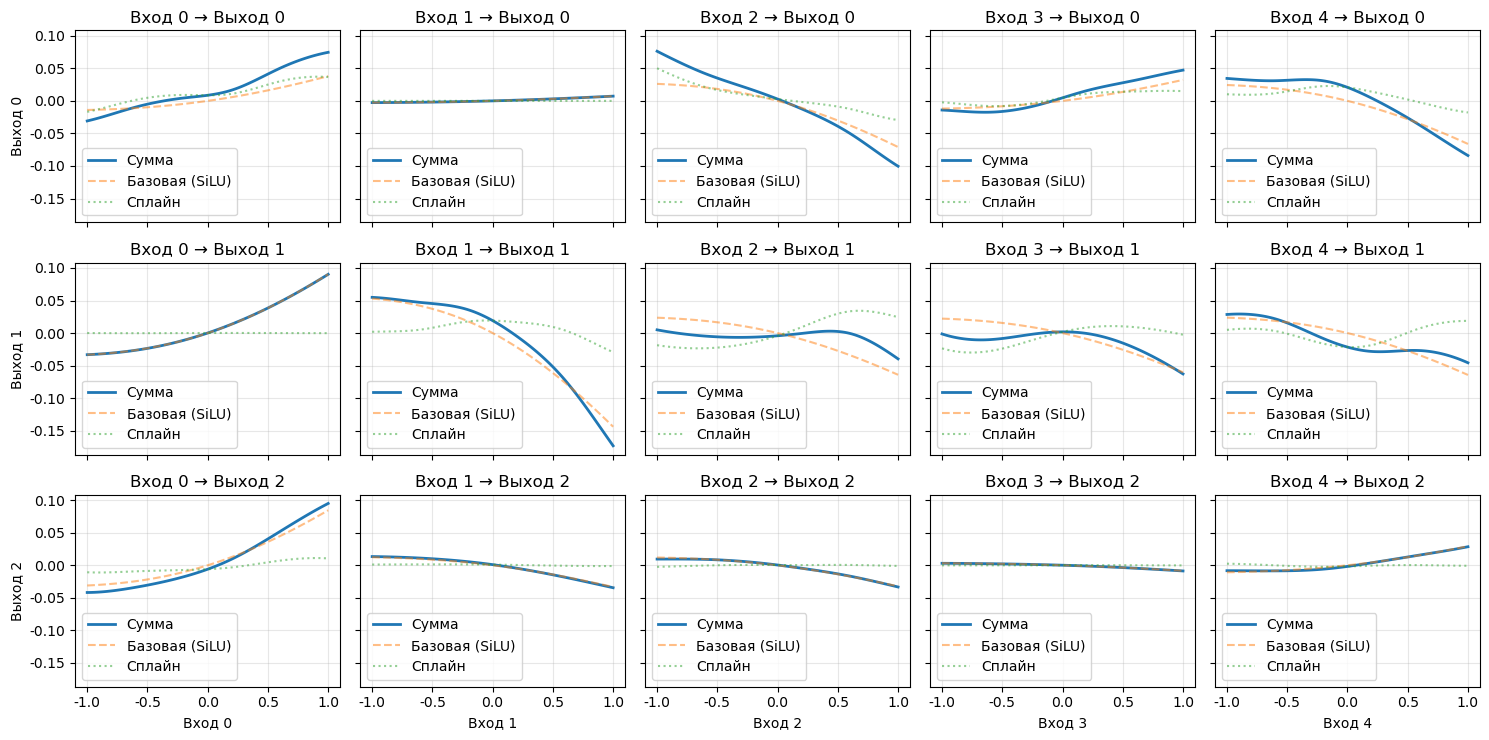

Сохранено: D:\Программирование\Fork\Scientific_research_osc_ML\reports\figures\Exp_2.6.1_PhysicsKAN_medium_phase_polar_stride_base_weights_aug_kan_classifier0.png


In [25]:
# === Визуализация KAN-слоёв ===
out_dir = FIGURES_DIR

# 1. Первый сверточный KAN-слой (если модель - ConvKAN или PhysicsKAN с Conv-блоком)
try:
    if hasattr(model, 'processing_net') and hasattr(model.processing_net, 'features'):
        conv_layer = model.processing_net.features[0]
        # Проверяем, KANConv1d ли это
        if hasattr(conv_layer, 'kan_linear'):
            kan_linear = conv_layer.kan_linear
        elif hasattr(conv_layer, 'kan_layer'):
            kan_linear = conv_layer.kan_layer
        else:
            kan_linear = None
            
        if kan_linear:
            print(f"Conv KAN Layer: in={kan_linear.in_features}, out={kan_linear.out_features}")
            fig = plot_kan_layer_grid(
                kan_linear, 
                max_inputs=5, 
                max_outputs=3,
                save_path=out_dir / f"{EXP_NAME}_kan_conv_layer0.png",
                show=True
            )
            print(f"Сохранено: {out_dir / f'{EXP_NAME}_kan_conv_layer0.png'}")
except Exception as e:
    print(f"Ошибка при визуализации сверточного слоя: {e}")

# 2. Первый слой классификатора
try:
    if hasattr(model, 'processing_net') and hasattr(model.processing_net, 'classifier'):
        clf_layer = model.processing_net.classifier[0]
        print(f"Classifier KAN Layer: in={clf_layer.in_features}, out={clf_layer.out_features}")
        
        fig_clf = plot_kan_layer_grid(
            clf_layer,
            max_inputs=5,
            max_outputs=3,
            save_path=out_dir / f"{EXP_NAME}_kan_classifier0.png",
            show=True
        )
        print(f"Сохранено: {out_dir / f'{EXP_NAME}_kan_classifier0.png'}")
    elif hasattr(model, 'processing_net') and hasattr(model.processing_net, 'net'):
        # Для SimpleKAN
        clf_layer = model.processing_net.net[0]
        if hasattr(clf_layer, 'in_features'):
            print(f"SimpleKAN first layer: in={clf_layer.in_features}, out={clf_layer.out_features}")
            fig_clf = plot_kan_layer_grid(
                clf_layer,
                max_inputs=5,
                max_outputs=3,
                save_path=out_dir / f"{EXP_NAME}_kan_simple0.png",
                show=True
            )
except Exception as e:
    print(f"Ошибка при визуализации слоя классификатора: {e}")

## Важность связей и вклад арифметических слоёв

Далее мы оценим важность связей KAN на реальных данных (среднее $|\phi(x)|$)
и посмотрим базовые статистики по выходам `MultiplicationLayer` и `DivisionLayer`,
чтобы понять вклад физических преобразований в сигнал.

Сбор входов KANLinear...
Расчёт важностей |phi(x)|...
Найдено KANLinear слоёв: 5


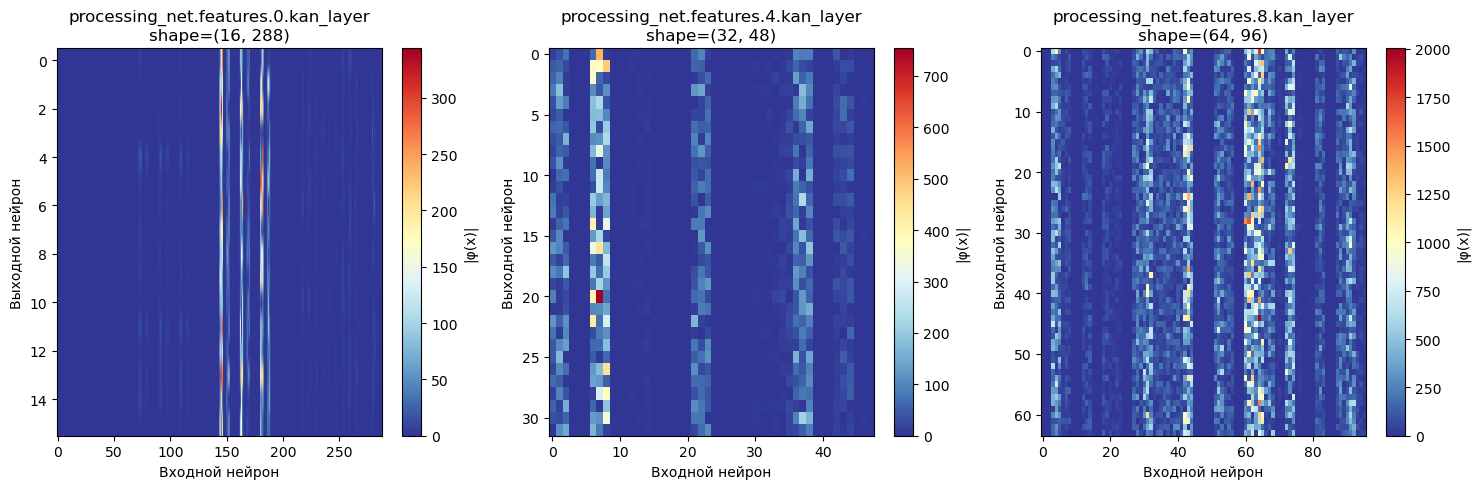

Сохранено: D:\Программирование\Fork\Scientific_research_osc_ML\reports\figures\Exp_2.6.1_PhysicsKAN_medium_phase_polar_stride_base_weights_aug_importance_heatmap.png

Статистика важности по слоям:
  processing_net.features.0.kan_layer: mean=4.7560, max=344.1965, zeros=5.6%
  processing_net.features.4.kan_layer: mean=24.6458, max=754.4401, zeros=0.4%
  processing_net.features.8.kan_layer: mean=120.1242, max=2005.2136, zeros=0.2%
  processing_net.classifier.0: mean=120.5093, max=2164.7539, zeros=1.6%
  processing_net.classifier.1: mean=121.7748, max=1042.1002, zeros=3.1%

Вклад арифметических слоёв:
  Raw input:  mean=4.2450, max=43.7292
  Mult layer: mean=4.0508, max=51.4331
  Div layer:  mean=53737.0973, max=3285925.3750


In [24]:
# === Важность связей KAN и вклад арифметических слоёв ===
from torch.utils.data import DataLoader
from osc_tools.ml.kan_pruning import collect_kan_inputs, calculate_kan_importance

# Создание простого DataLoader для сбора активаций
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

if 'ds' in locals() and ds is not None:
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)

    print("Сбор входов KANLinear...")
    inputs = collect_kan_inputs(model, loader, device, max_batches=5, max_samples=1000)

    print("Расчёт важностей |phi(x)|...")
    importances = calculate_kan_importance(model, inputs, device)
    print(f"Найдено KANLinear слоёв: {len(importances)}")

    # === Визуализация матрицы важности ===
    if importances:
        fig, axes = plt.subplots(1, min(3, len(importances)), figsize=(15, 5))
        if len(importances) == 1:
            axes = [axes]
        
        for idx, (layer_name, imp_tensor) in enumerate(list(importances.items())[:3]):
            scores = imp_tensor.cpu().numpy() # Перенос на CPU перед numpy
            ax = axes[idx]
            
            im = ax.imshow(scores, aspect='auto', cmap='RdYlBu_r', vmin=0, vmax=scores.max())
            ax.set_title(f'{layer_name}\nshape={scores.shape}')
            ax.set_xlabel('Входной нейрон')
            ax.set_ylabel('Выходной нейрон')
            plt.colorbar(im, ax=ax, label='|φ(x)|')
        
        plt.tight_layout()
        save_path = FIGURES_DIR / f"{EXP_NAME}_importance_heatmap.png"
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Сохранено: {save_path}")

    # === Статистики по слоям ===
    print("\nСтатистика важности по слоям:")
    for layer_name, imp_tensor in importances.items():
        scores = imp_tensor.cpu().numpy() # Перенос на CPU
        print(f"  {layer_name}: mean={scores.mean():.4f}, max={scores.max():.4f}, ", end='')
        print(f"zeros={np.sum(scores < 0.001) / scores.size * 100:.1f}%")

    # === Вклад арифметических слоёв (Mult/Div) ===
    if hasattr(model, 'mult') and hasattr(model, 'div'):
        print("\nВклад арифметических слоёв:")
        raw_stats, mult_stats, div_stats = [], [], []
        
        with torch.no_grad():
            for i, batch in enumerate(loader):
                x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
                mult_out = model.mult(x)
                div_out = model.div(x)
                
                raw_stats.append((x.abs().mean().item(), x.abs().max().item()))
                mult_stats.append((mult_out.abs().mean().item(), mult_out.abs().max().item()))
                div_stats.append((div_out.abs().mean().item(), div_out.abs().max().item()))
                if i >= 5:
                    break
        
        print(f"  Raw input:  mean={np.mean([s[0] for s in raw_stats]):.4f}, max={np.mean([s[1] for s in raw_stats]):.4f}")
        print(f"  Mult layer: mean={np.mean([s[0] for s in mult_stats]):.4f}, max={np.mean([s[1] for s in mult_stats]):.4f}")
        print(f"  Div layer:  mean={np.mean([s[0] for s in div_stats]):.4f}, max={np.mean([s[1] for s in div_stats]):.4f}")
    else:
        print("\nМодель не содержит MultiplicationLayer/DivisionLayer")
else:
    print("Ошибка: Датасет 'ds' не найден. Пожалуйста, выполните ячейку загрузки данных (Cell 3).")

## Выводы

### Интерпретация результатов:

1. **Функции активации KAN** - показывают нелинейные преобразования, которые выучила модель.
   - Base component (синий) - линейная часть (SiLU * x)
   - Spline component (оранжевый) - изученный сплайн
   - Total (base+spline, зелёный) - финальная функция

2. **Матрица важности** - показывает |φ(x)| для каждой связи вход-выход.
   - Высокие значения = важные связи
   - Низкие значения = можно удалить (pruning)

3. **Арифметические слои (Mult/Div)** - физически интерпретируемые преобразования.
   - Если Div даёт большие значения - возможны численные проблемы
   - Результаты из Exp 2.6.5: mult критичен (удаление сильно падает F1), div менее важен